<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Nighttime_Light_Pollution_County_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

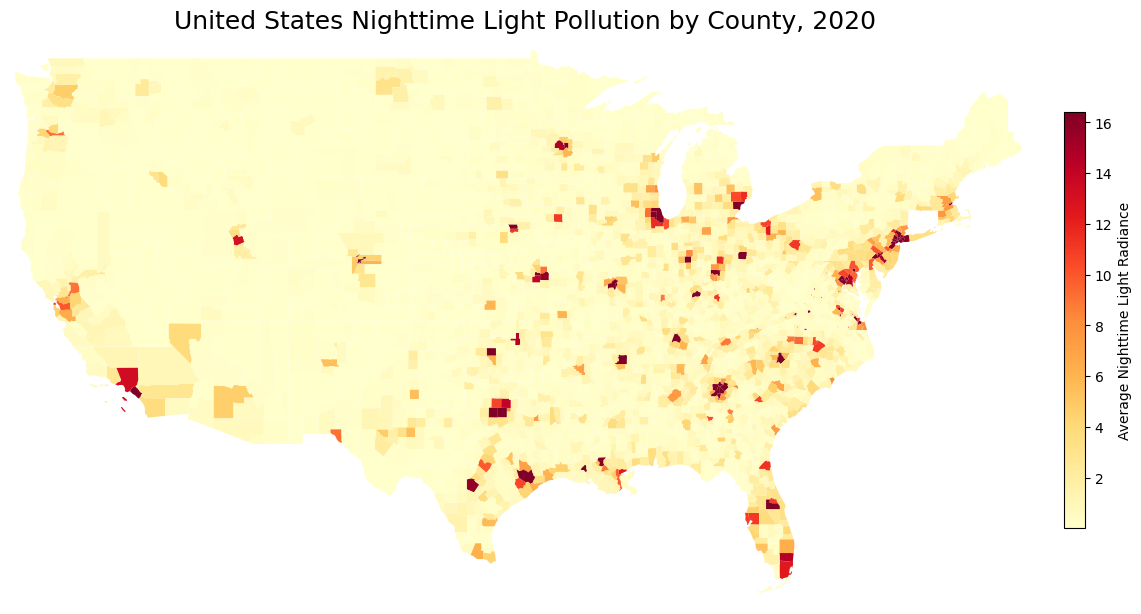

In [6]:
# Run once
# !pip install geopandas pandas numpy matplotlib openpyxl

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read Excel file
file = "/content/ALAN_VIIRS_CONUS_2012_to_2020_census_tract_level.xlsx"

alan_data = pd.read_excel(
    file,
    sheet_name="2020_boundary_ALAN_2012_to_2020"
)

# Keep only 2020 data
alan_2020 = alan_data[alan_data["year"] == 2020].copy()

# Make sure important columns are numeric
alan_2020["rad_mean"] = pd.to_numeric(alan_2020["rad_mean"], errors="coerce")
alan_2020["nraster"] = pd.to_numeric(alan_2020["nraster"], errors="coerce")

# Remove missing values
alan_2020 = alan_2020[
    alan_2020["rad_mean"].notna() &
    alan_2020["nraster"].notna()
].copy()

# Make county FIPS match shapefile GEOID
alan_2020["county_ID"] = (
    alan_2020["county_ID"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Calculate weighted radiance
alan_2020["weighted_rad"] = alan_2020["rad_mean"] * alan_2020["nraster"]

# Group census tract data into county-level data
county_light = alan_2020.groupby("county_ID").agg({
    "weighted_rad": "sum",
    "nraster": "sum",
    "county": "first",
    "state": "first"
}).reset_index()

# Calculate true average radiance by county
county_light["true_rad_mean"] = county_light["weighted_rad"] / county_light["nraster"]

# Read county shapefile from Census
county_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"

counties = gpd.read_file(county_url)

# Merge county shapes with nighttime light data
merged = counties.merge(
    county_light,
    left_on="GEOID",
    right_on="county_ID",
    how="left"
)

# Keep lower 48 states
lower48 = merged.cx[-125:-66, 24:50].copy()


lower48["rad_mean"] = pd.to_numeric(lower48["true_rad_mean"], errors="coerce")


vmin = lower48["rad_mean"].quantile(0.02)
vmax = lower48["rad_mean"].quantile(0.98)

# Make map
fig, ax = plt.subplots(figsize=(16, 9))

lower48.plot(
    column="rad_mean",
    cmap="YlOrRd",
    legend=True,
    edgecolor="none",
    linewidth=0,
    vmin=vmin,
    vmax=vmax,
    ax=ax,
    legend_kwds={
        "label": "Average Nighttime Light Radiance",
        "orientation": "vertical",
        "shrink": 0.6,
        "pad": 0.02
    }
)

ax.set_title("United States Nighttime Light Pollution by County, 2020", fontsize=18)
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis("off")

plt.show()